In [23]:
import xarray as xr 
import numpy as np 
from shapely import Polygon
from pathlib import Path

import matplotlib.pyplot as plt

import sys
import os
project_root = str(Path(os.getcwd()).parent)

if project_root not in sys.path:
    sys.path.append(project_root)

%load_ext autoreload
%autoreload 2
# from scripts.layers import assemble_data, get_uavsar_coherence, get_uavsar_incidence, get_nlcd_layers
from scripts.layers import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
geo_dir = data_dir + 'uavsar_geoslcs/'

img1x1 = geo_dir + 'stlake/27129/stlake_27129_20007_004_200213_L090VV_01_BC_s1_1x1.slc.complex.tif'
img2x8 = geo_dir + 'stlake/27129/stlake_27129_20007_004_200213_L090VV_01_BC_s1_2x8.slc.complex.tif'

In [10]:
aoi = Polygon([
    (-111.7332140938517, 40.6079909188825),
    (-111.7307874732357, 40.58585096349459),
    (-111.6857755957641, 40.58703464363237),
    (-111.6873712400506, 40.60845482790766),
    (-111.7332140938517, 40.6079909188825)
])

minx, miny, maxx, maxy = aoi.bounds

In [24]:
arr1x1 = xr.open_dataset(img1x1)
arr1x1 = arr1x1.sel(x=slice(minx, maxx), y=slice(maxy, miny))

print(arr1x1)

<xarray.Dataset> Size: 147MB
Dimensions:      (band: 1, x: 6205, y: 2957)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 50kB -111.7 -111.7 -111.7 ... -111.7 -111.7 -111.7
  * y            (y) float64 24kB 40.61 40.61 40.61 40.61 ... 40.59 40.59 40.59
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) complex64 147MB ...


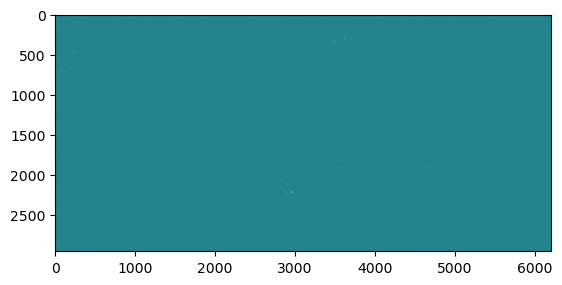

In [26]:
fig, ax = plt.subplots()

ax.imshow(arr1x1['band_data'].values.squeeze().real)
plt.show()

In [4]:
arr2x8 = xr.open_dataset(img2x8)
arr2x8

<xarray.Dataset> Size: 193MB
Dimensions:      (band: 1, x: 6861, y: 3523)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 55kB -111.8 -111.8 -111.8 ... -111.4 -111.4 -111.4
  * y            (y) float64 28kB 40.71 40.71 40.71 40.71 ... 40.51 40.51 40.51
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) complex64 193MB ...